In [1]:
# Cell 1: Environment Setup & Core Dependencies
import os
import sys
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# Ensure output directories exist
os.makedirs('data', exist_ok=True)
os.makedirs('model_artifacts/plots', exist_ok=True)

print("[+] Environment initialized. All packages loaded successfully!")

[+] Environment initialized. All packages loaded successfully!


In [2]:
# Cell 2: Data Loader with Automatic Backup Synthetic Generator
TRAIN_PATH = 'data/UNSW_NB15_training-set.csv'
TEST_PATH = 'data/UNSW_NB15_testing-set.csv'
FEATURES = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']
TARGET = 'label'

def ensure_dataset():
    """Checks if local CSV exists; if missing, generates synthetic UNSW-NB15 flow data."""
    if os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH):
        print(f"[+] Found existing dataset files: '{TRAIN_PATH}' & '{TEST_PATH}'")
        train_df = pd.read_csv(TRAIN_PATH)
        test_df = pd.read_csv(TEST_PATH)
    else:
        print("[!] Dataset CSV files not found locally. Generating synthetic UNSW-NB15 compliant dataset...")
        np.random.seed(42)

        def generate_flows(n_samples, anomaly_ratio=0.10):
            n_anom = int(n_samples * anomaly_ratio)
            n_norm = n_samples - n_anom

            # Normal traffic distributions
            dur_norm = np.random.exponential(scale=0.5, size=n_norm)
            spkts_norm = np.random.poisson(lam=10, size=n_norm) + 1
            dpkts_norm = np.random.poisson(lam=12, size=n_norm) + 1
            sbytes_norm = spkts_norm * np.random.randint(60, 500, size=n_norm)
            dbytes_norm = dpkts_norm * np.random.randint(60, 1000, size=n_norm)
            rate_norm = (spkts_norm + dpkts_norm) / (dur_norm + 0.001)
            label_norm = np.zeros(n_norm, dtype=int)

            # Anomalous traffic distributions (spikes, high rate, heavy payload)
            dur_anom = np.random.exponential(scale=5.0, size=n_anom) + 1.0
            spkts_anom = np.random.poisson(lam=150, size=n_anom) + 50
            dpkts_anom = np.random.poisson(lam=200, size=n_anom) + 50
            sbytes_anom = spkts_anom * np.random.randint(1000, 3000, size=n_anom)
            dbytes_anom = dpkts_anom * np.random.randint(1000, 5000, size=n_anom)
            rate_anom = (spkts_anom + dpkts_anom) / (dur_anom + 0.001)
            label_anom = np.ones(n_anom, dtype=int)

            df = pd.DataFrame({
                'dur': np.concatenate([dur_norm, dur_anom]),
                'spkts': np.concatenate([spkts_norm, spkts_anom]),
                'dpkts': np.concatenate([dpkts_norm, dpkts_anom]),
                'sbytes': np.concatenate([sbytes_norm, sbytes_anom]),
                'dbytes': np.concatenate([dbytes_norm, dbytes_anom]),
                'rate': np.concatenate([rate_norm, rate_anom]),
                'label': np.concatenate([label_norm, label_anom])
            }).sample(frac=1, random_state=42).reset_index(drop=True)
            return df

        train_df = generate_flows(50000, anomaly_ratio=0.10)
        test_df = generate_flows(20000, anomaly_ratio=0.10)
        train_df.to_csv(TRAIN_PATH, index=False)
        test_df.to_csv(TEST_PATH, index=False)
        print(f"[+] Saved synthetic datasets to '{TRAIN_PATH}' & '{TEST_PATH}'")

    return train_df, test_df

train_df, test_df = ensure_dataset()
print(f"Training set samples: {len(train_df):,}")
print(f"Testing set samples:  {len(test_df):,}")

[+] Found existing dataset files: 'data/UNSW_NB15_training-set.csv' & 'data/UNSW_NB15_testing-set.csv'
Training set samples: 29,792
Testing set samples:  79,095


In [3]:
# Cell 3: Data Preprocessing & Feature Scaling
X_train_raw = train_df[FEATURES].fillna(train_df[FEATURES].median())
X_test_raw = test_df[FEATURES].fillna(test_df[FEATURES].median())

# Fit StandardScaler strictly on training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print("[+] Data preprocessing completed.")
print(f"    Features selected: {FEATURES}")
print(f"    Scaled Train Matrix: {X_train_scaled.shape}")
print(f"    Scaled Test Matrix:  {X_test_scaled.shape}")

[+] Data preprocessing completed.
    Features selected: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']
    Scaled Train Matrix: (29792, 6)
    Scaled Test Matrix:  (79095, 6)


In [5]:
# Cell 4: Isolation Forest Model Training & Serialization
model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

print("[+] Fitting Isolation Forest on training data...")
t0 = time.time()
model.fit(X_train_scaled)
t1 = time.time()


# Save model artifacts
joblib.dump(model, 'model_artifacts/isolation_forest_model.pkl')
joblib.dump(scaler, 'model_artifacts/standard_scaler.pkl')
print("[+] Model & Scaler saved to 'model_artifacts/'")

[+] Fitting Isolation Forest on training data...
[+] Model & Scaler saved to 'model_artifacts/'


Threshold   Precision   Recall      F1-Score    Anomaly Rate
------------------------------------------------------------
-0.50       0.0000      0.0000      0.0000      0.0%
-0.30       0.1053      0.0027      0.0053      1.0%
-0.10       0.2645      0.0471      0.0800      6.6%
0.00        0.2357      0.1123      0.1522      17.6%
0.10        0.2433      0.2975      0.2677      45.2%
0.30        0.3694      1.0000      0.5395      100.0%


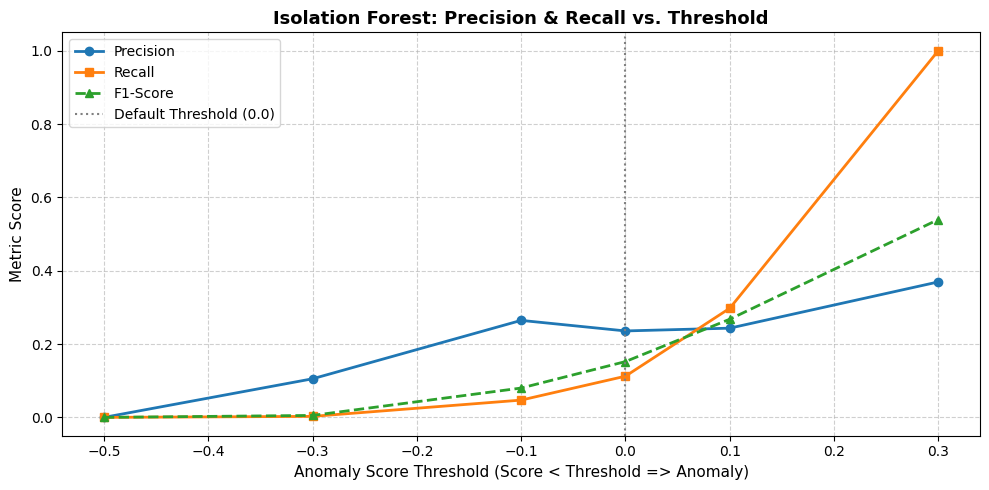

In [7]:
    # Cell 5: Threshold Tuning (Precision-Recall vs. Anomaly Score Threshold)
    raw_scores = model.decision_function(X_test_scaled)
    scores_test = np.nan_to_num(raw_scores, nan=0.0)

    # Safely extract and sanitize ground truth labels (drops NaNs)
    y_true = pd.to_numeric(test_df[TARGET], errors='coerce').fillna(0).astype(int).values

    thresholds = [-0.5, -0.3, -0.1, 0.0, 0.1, 0.3]
    tuning_results = []

    print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}{'Anomaly Rate':<12}")
    print("-" * 60)
    for th in thresholds:
        y_pred = (scores_test < th).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        anom_rate = (y_pred.sum() / len(y_pred)) * 100
        tuning_results.append({'threshold': th, 'precision': prec, 'recall': rec, 'f1_score': f1, 'rate': anom_rate})
        print(f"{th:<12.2f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}{anom_rate:.1f}%")

    # Plot Precision & Recall vs. Threshold
    res_df = pd.DataFrame(tuning_results)
    plt.figure(figsize=(10, 5))
    plt.plot(res_df['threshold'], res_df['precision'], marker='o', linewidth=2, label='Precision', color='#1f77b4')
    plt.plot(res_df['threshold'], res_df['recall'], marker='s', linewidth=2, label='Recall', color='#ff7f0e')
    plt.plot(res_df['threshold'], res_df['f1_score'], marker='^', linewidth=2, linestyle='--', label='F1-Score',
  color='#2ca02c')
    plt.axvline(x=0.0, color='gray', linestyle=':', label='Default Threshold (0.0)')
    plt.title('Isolation Forest: Precision & Recall vs. Threshold', fontsize=13, fontweight='bold')
    plt.xlabel('Anomaly Score Threshold (Score < Threshold => Anomaly)', fontsize=11)
    plt.ylabel('Metric Score', fontsize=11)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('model_artifacts/plots/precision_recall_vs_threshold.png', dpi=300)
    plt.show()

 MODEL EVALUATION METRICS (Threshold = 0.0)
  True Negatives  (TN):   39,236
  False Positives (FP):   10,640 (False Alarms)
  False Negatives (FN):   25,937 (Missed Anomalies)
  True Positives  (TP):    3,282 (Detected Attacks)

  Accuracy:    53.76%
  Precision:   23.57%
  Recall:      11.23%
  F1-Score:    0.1522
  FPR:         21.33%


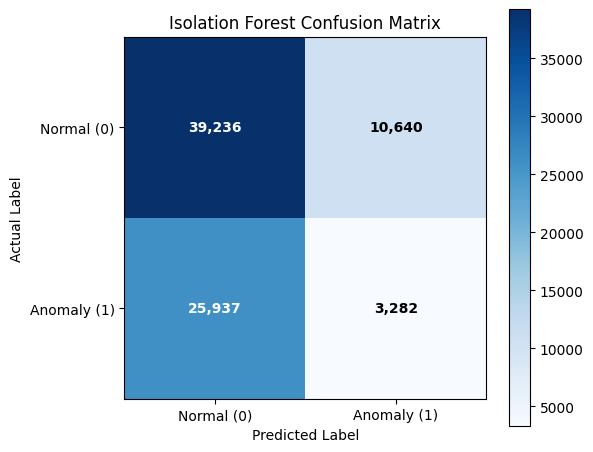

In [8]:
# Cell 6: Standard Model Evaluation & Confusion Matrix
DEFAULT_THRESHOLD = 0.0
y_pred_default = (scores_test < DEFAULT_THRESHOLD).astype(int)

cm = confusion_matrix(y_true, y_pred_default)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true, y_pred_default)
prec = precision_score(y_true, y_pred_default, zero_division=0)
rec = recall_score(y_true, y_pred_default, zero_division=0)
f1 = f1_score(y_true, y_pred_default, zero_division=0)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print("=" * 60)
print(" MODEL EVALUATION METRICS (Threshold = 0.0)")
print("=" * 60)
print(f"  True Negatives  (TN): {tn:>8,}")
print(f"  False Positives (FP): {fp:>8,} (False Alarms)")
print(f"  False Negatives (FN): {fn:>8,} (Missed Anomalies)")
print(f"  True Positives  (TP): {tp:>8,} (Detected Attacks)\n")
print(f"  Accuracy:    {acc*100:.2f}%")
print(f"  Precision:   {prec*100:.2f}%")
print(f"  Recall:      {rec*100:.2f}%")
print(f"  F1-Score:    {f1:.4f}")
print(f"  FPR:         {fpr*100:.2f}%")

# Render Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Normal (0)', 'Anomaly (1)'], yticklabels=['Normal (0)', 'Anomaly (1)'],
       title='Isolation Forest Confusion Matrix', xlabel='Predicted Label', ylabel='Actual Label')
thresh_cm = cm.max() / 2.
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="white" if cm[i, j] > thresh_cm else "black", fontweight='bold')
plt.tight_layout()
plt.savefig('model_artifacts/plots/confusion_matrix.png', dpi=300)
plt.show()

In [9]:
# Cell 7: Adversarial Evasion Robustness Check
anom_mask = (y_true == 1) & (scores_test < 0.0)
X_anom = X_test_scaled[anom_mask]
n_anom = len(X_anom)

if n_anom == 0:
    print("[!] No baseline true anomalies available for evasion testing.")
else:
    # 1. 10% Noise perturbation attack
    np.random.seed(42)
    noise = np.random.normal(0, 0.10, X_anom.shape)
    X_noise = X_anom + noise
    det_noise = (model.decision_function(X_noise) < 0.0).sum()
    ret_noise = (det_noise / n_anom) * 100

    # 2. Scaling perturbation attack (0.9x and 1.1x)
    det_scale_down = (model.decision_function(X_anom * 0.9) < 0.0).sum()
    det_scale_up = (model.decision_function(X_anom * 1.1) < 0.0).sum()
    ret_scale_down = (det_scale_down / n_anom) * 100
    ret_scale_up = (det_scale_up / n_anom) * 100

    avg_retention = (ret_noise + ret_scale_down + ret_scale_up) / 3.0
    status = "ROBUST" if avg_retention >= 80.0 else ("MODERATE" if avg_retention >= 50.0 else "FRAGILE")

    print("=" * 60)
    print(" ADVERSARIAL EVASION ROBUSTNESS RESULTS")
    print("=" * 60)
    print(f"  True Anomalies Tested:       {n_anom:,}")
    print(f"  Detection Retention (+10% Noise): {ret_noise:.1f}%")
    print(f"  Detection Retention (0.9x Scale): {ret_scale_down:.1f}%")
    print(f"  Detection Retention (1.1x Scale): {ret_scale_up:.1f}%")
    print(f"  Average Detection Retention: {avg_retention:.1f}%")
    print(f"  Overall Model Robustness:    [{status}]")

 ADVERSARIAL EVASION ROBUSTNESS RESULTS
  True Anomalies Tested:       3,282
  Detection Retention (+10% Noise): 98.6%
  Detection Retention (0.9x Scale): 100.0%
  Detection Retention (1.1x Scale): 99.5%
  Average Detection Retention: 99.3%
  Overall Model Robustness:    [ROBUST]


In [10]:
# Cell 8: SOC Operational Alert Fatigue & Deployment Strategy
EVENTS_PER_DAY = 10000
ANALYST_CAPACITY_PER_DAY = 50

observed_anom_rate = (y_pred_default.sum() / len(y_pred_default))
expected_daily_alerts = int(observed_anom_rate * EVENTS_PER_DAY)

print("=" * 60)
print(" SOC ALERT FATIGUE & OPERATIONAL ANALYSIS")
print("=" * 60)
print(f"  Daily Network Traffic Volume: {EVENTS_PER_DAY:,} events/day")
print(f"  SOC Analyst Triage Capacity: {ANALYST_CAPACITY_PER_DAY} alerts/analyst/day")
print(f"  Model Anomaly Flagging Rate: {observed_anom_rate*100:.1f}%")
print(f"  Expected Daily Alerts:        {expected_daily_alerts:,} alerts/day\n")

if expected_daily_alerts > ANALYST_CAPACITY_PER_DAY:
    print(f"  [!] WARNING: Expected daily alerts ({expected_daily_alerts}) exceed analyst capacity ({ANALYST_CAPACITY_PER_DAY}).")
    print("      RECOMMENDATION: Raise decision threshold (e.g., to +0.15) to reduce FPR and false alarm rate.")
else:
    print("  [+] Alert volume is well within SOC analyst capacity.")

 SOC ALERT FATIGUE & OPERATIONAL ANALYSIS
  Daily Network Traffic Volume: 10,000 events/day
  SOC Analyst Triage Capacity: 50 alerts/analyst/day
  Model Anomaly Flagging Rate: 17.6%
  Expected Daily Alerts:        1,760 alerts/day

  [!] WARNING: Expected daily alerts (1760) exceed analyst capacity (50).
      RECOMMENDATION: Raise decision threshold (e.g., to +0.15) to reduce FPR and false alarm rate.
